In [89]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [90]:
import torch.distributions as dist

def mixture_sample_with_labels(self, sample_shape=torch.Size()):
    labels = self.mixture_distribution.sample(sample_shape)
    all_samples = self.component_distribution.sample(sample_shape)
    x_samples = all_samples[torch.arange(len(labels)), labels]
    return x_samples, labels


# Circular GMM Class
class CircularGMM(dist.MixtureSameFamily):
    def __init__(
        self, n_components=6, radius=10, dim=2, std=1.0, device=torch.device("cpu")
    ):
        self.device = device
        angles = torch.linspace(0, 2 * torch.pi, n_components + 1)[:-1].to(device)
        means = torch.stack(
            [radius * torch.cos(angles), radius * torch.sin(angles)], dim=1
        ).to(device)
        stds = std * torch.ones(n_components, dim).to(device)
        weights = torch.ones(n_components).to(device) / n_components

        # Initialize the MixtureSameFamily distribution
        super().__init__(
            dist.Categorical(weights), dist.Independent(dist.Normal(means, stds), 1)
        )

    def sample_with_labels(self, sample_shape=torch.Size()):
        return mixture_sample_with_labels(self, sample_shape)


# Two-point GMM Class
class TwoPointGMM(dist.MixtureSameFamily):
    def __init__(self, x=10.0, y=10.0, std=1.0, device=torch.device("cpu")):
        self.device = device
        means = torch.tensor([[x, y], [x, -y]]).to(device)
        stds = torch.ones(2, 2).to(device) * std
        weights = torch.ones(2).to(device) / 2

        # Initialize the MixtureSameFamily distribution
        super().__init__(
            dist.Categorical(weights), dist.Independent(dist.Normal(means, stds), 1)
        )

    def sample_with_labels(self, sample_shape=torch.Size()):
        return mixture_sample_with_labels(self, sample_shape)

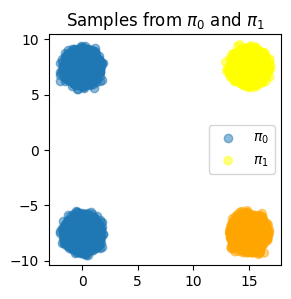

In [127]:
from matplotlib import pyplot as plt
import numpy as np

n_samples = 50000
pi_0 = TwoPointGMM(x=0.0, y=7.5, std=0.5, device=device)
pi_1 = TwoPointGMM(x=15.0, y=7.5, std=0.5, device=device)
D0 = pi_0.sample([n_samples])
D1, labels = pi_1.sample_with_labels([n_samples])

labels = labels.float()  # or labels.to(torch.float32)  
labels.tolist()
colors = np.where(labels.cpu() == 0, 'yellow', 'orange')

plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(D0[:, 0].cpu(), D0[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(D1[:, 0].cpu(), D1[:, 1].cpu(), alpha=0.5, c=colors, label=r'$\pi_1$')
plt.legend()

In [115]:
from cleandiffuser.diffusion import DiscreteRectifiedFlow
from cleandiffuser.nn_diffusion import MlpNNDiffusion
from cleandiffuser.nn_condition import MLPCondition  # Assuming this is the correct import

# Define the neural network backbone
nn_diffusion = MlpNNDiffusion(x_dim=2, hidden_dims=[128, 128, 128], emb_dim=64)
nn_condition = MLPCondition(in_dim=1, out_dim=64, hidden_dims=[128], dropout=0.25)  # Define the condition network

# Initialize the discrete rectified flow model
model = DiscreteRectifiedFlow(
    nn_diffusion=nn_diffusion,
    nn_condition=nn_condition,
    diffusion_steps=1000,
    discretization="uniform",
    device=device,
)

In [116]:
from torch.utils.data import DataLoader, TensorDataset  

batch_size = 1024

# Create a dataset and dataloader for batching  
dataset = TensorDataset(D1, D0, labels)  
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)  

# Training loop with proper batching  
n_epochs = 102  
for epoch in range(n_epochs):  
    total_loss = 0  
    for batch_d1, batch_d0, batch_labels in dataloader:  
        
        if batch_labels.shape != (batch_labels.shape[0], 1):  
            batch_labels = batch_labels.reshape(-1, 1)  

        log = model.update(x0=batch_d1, x1=batch_d0, condition=batch_labels)  
        total_loss += log['loss']  
      
    avg_loss = total_loss / len(dataloader)  
    print(f"Epoch {epoch}, Average Loss: {avg_loss}")

Epoch 0, Average Loss: 150.50737497757893
Epoch 1, Average Loss: 69.76371157899194
Epoch 2, Average Loss: 56.99994223458426
Epoch 3, Average Loss: 42.502455419423626
Epoch 4, Average Loss: 22.556577682495117
Epoch 5, Average Loss: 17.13333700141128
Epoch 6, Average Loss: 15.536119246969418
Epoch 7, Average Loss: 14.034928574854014
Epoch 8, Average Loss: 13.02891986224116
Epoch 9, Average Loss: 11.859328445123166
Epoch 10, Average Loss: 11.2751471461082
Epoch 11, Average Loss: 10.599548592859385
Epoch 12, Average Loss: 10.228774421069087
Epoch 13, Average Loss: 9.634219578334264
Epoch 14, Average Loss: 9.107216465229891
Epoch 15, Average Loss: 8.642550351668378
Epoch 16, Average Loss: 8.170518758345624
Epoch 17, Average Loss: 7.665974558616171
Epoch 18, Average Loss: 7.386172158377511
Epoch 19, Average Loss: 7.167119347319311
Epoch 20, Average Loss: 6.8662267217830735
Epoch 21, Average Loss: 6.605632723594199
Epoch 22, Average Loss: 6.581398993122335
Epoch 23, Average Loss: 6.4743789458

In [157]:
import torch

# Define the number of samples and the shape of each sample
n_samples = 500
x_shape = (2,)  # Shape of each sample
sample_steps=1
x1 = pi_0.sample([n_samples]) # Sample from the second distribution
# Create a prior tensor with the appropriate shape
prior = torch.zeros((n_samples, *x_shape))

conditioned_label = 1.0 # 0.0
class_condition = torch.tensor([[conditioned_label]] * n_samples, device=device, dtype=torch.float32)  
condition_cfg = class_condition # or 0.0 or None
w_cfg = 1.0  # Weight configuration, 1.0 is class conditioned, 0.0 is unconditional

# Print the shapes for verification
print(f"Sampling {n_samples} samples with shape {x_shape} from the prior. Prior shape: {prior.shape}")

# Example sampling using a model
# Assuming `model` is an instance of DiscreteRectifiedFlow or ContinuousRectifiedFlow
samples, log = model.sample(n_samples=n_samples, prior=prior, sample_steps=sample_steps, x1=x1, preserve_history=True, condition_cfg=condition_cfg, w_cfg=w_cfg)

# Output the shape of the generated samples
print(f"Generated samples shape: {samples.shape}")


Sampling 500 samples with shape (2,) from the prior. Prior shape: torch.Size([500, 2])
Generated samples shape: torch.Size([500, 2])


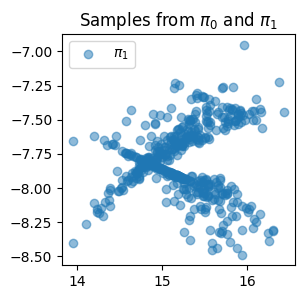

In [158]:
plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
# plt.scatter(x1[:, 0].cpu(), x1[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), alpha=0.5, label=r'$\pi_1$')
plt.legend()

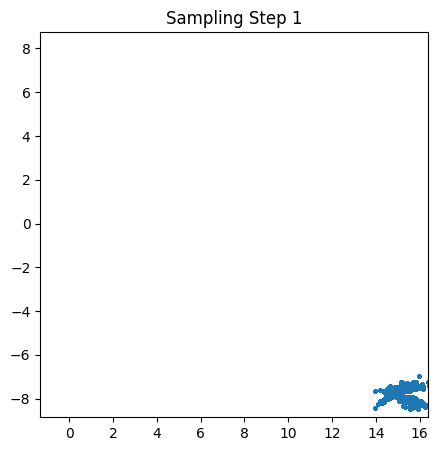

In [159]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# sample_history: (n_samples, sample_steps + 1, num_points, 2)
sample_history = log['sample_history']
n_steps = sample_history.shape[1]

fig, ax = plt.subplots(figsize=(5, 5))
scat = ax.scatter([], [], s=n_steps, alpha=0.5)
ax.set_xlim(np.min(sample_history[..., 0]), np.max(sample_history[..., 0]))
ax.set_ylim(np.min(sample_history[..., 1]), np.max(sample_history[..., 1]))
ax.set_title("Sample Evolution")
ax.axis("equal")

def update(frame):
    points = sample_history[:, frame].reshape(-1, 2)
    scat.set_offsets(points)
    ax.set_title(f"Sampling Step {frame}")
    return scat,

ani = FuncAnimation(fig, update, frames=n_steps, blit=True, interval=500)
HTML(ani.to_jshtml())
